In [1]:
import numpy as np
import matplotlib.pyplot as plt
from parflow.tools import Run
from parflow.tools.fs import mkdir, cp, get_absolute_path, exists
import matplotlib.pyplot as plt
from matplotlib import colors 
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
from matplotlib.colors import TwoSlopeNorm
import matplotlib.patches as mpatches
from matplotlib.patches import Patch

from matplotlib.ticker import MultipleLocator

In [3]:
runname = 'baseline.wy2017'
run_dir=''
run_dir = get_absolute_path(runname)

path_run = f'~/{runname}/'
run = Run.from_definition(f'{path_run}{runname}.pfidb')

data = run.data_accessor # creating data accessor object 
dx = data.dx
dy = data.dy
dz = data.dz

nz,ny,nx = data.shape

porosity= data.computed_porosity
specific_storage = data.specific_storage
mask = data.mask
mask[mask>0]=1 # PF has big # instead of 1 so change to 1 bc more manageable
surf_mask = mask[-1,:,:] # last element of first axis (always be surface no matter what)
nanmask=mask.copy()
nanmask[nanmask == 0] = 'NaN'
nanmask[nanmask > 0] = 1

Solver: Field BinaryOutDir is not part of the expected schema <class 'parflow.tools.database.generated.Solver'>
  - nt
  - sw_ini
  - hkdepth
  - wtfact
  - trsmx0
  - smpmax
  - pondmx


/home/ad4430/.local/lib/python3.9/site-packages/parflow/tools/io.py:1300: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_name, delim_whitespace=True, skiprows=2, header=None)


# read in arrays

In [ ]:
evaptrans_wet_b = np.load('~/pf_out_WY2017_baseline/evaptrans.npy')
evaptrans_wet_w = np.load('~/pf_out_WY2017_warm/evaptrans.npy')

evaptrans_dry_b = np.load('~/pf_out_WY2018_baseline/evaptrans.npy')
evaptrans_dry_w = np.load('~/pf_out_WY2018_warm/evaptrans.npy')

evaptrans_wet_b_rz0 = np.load('~/pf_out_WY2017_baseline_rz0/evaptrans.npy')
evaptrans_wet_w_rz0 = np.load('~/pf_out_WY2017_warm_rz0/evaptrans.npy')

evaptrans_dry_b_rz0 = np.load('~/pf_out_WY2018_baseline_rz0/evaptrans.npy')
evaptrans_dry_w_rz0 = np.load('~/pf_out_WY2018_warm_rz0/evaptrans.npy')


In [ ]:
tran_wet_b = np.load('~/pf_out_WY2017_baseline/transpiration.npy')
tran_dry_b = np.load('~/pf_out_WY2018_baseline/transpiration.npy')

tran_wet_b_rz0 = np.load('~/pf_out_WY2017_baseline_rz0/transpiration.npy')
tran_dry_b_rz0 = np.load('~/pf_out_WY2018_baseline_rz0/transpiration.npy')


tran_wet_w = np.load('~/pf_out_WY2017_warm/transpiration.npy')
tran_dry_w = np.load('~/pf_out_WY2018_warm/transpiration.npy')

tran_wet_w_rz0 = np.load('~/pf_out_WY2017_warm_rz0/transpiration.npy')
tran_dry_w_rz0 = np.load('~/pf_out_WY2018_warm_rz0/transpiration.npy')

In [ ]:
storage_wet_b = np.load('~/pf_out_WY2017_baseline/sub_storage.npy')
storage_dry_b = np.load('~/pf_out_WY2018_baseline/sub_storage.npy')

storage_wet_b_rz0 = np.load('~/pf_out_WY2017_baseline_rz0/sub_storage.npy')
storage_dry_b_rz0 = np.load('~/pf_out_WY2018_baseline_rz0/sub_storage.npy')


storage_wet_w = np.load('~/pf_out_WY2017_warm/sub_storage.npy')
storage_dry_w = np.load('~/pf_out_WY2018_warm/sub_storage.npy')

storage_wet_w_rz0 = np.load('~/pf_out_WY2017_warm_rz0/sub_storage.npy')
storage_dry_w_rz0 = np.load('~/pf_out_WY2018_warm_rz0/sub_storage.npy')

In [7]:
july_start_hr = 273*24
june_start_hr = 243*24

september_end_hr = 365*24


# ET by layer

In [8]:
evaptrans_wet_b = evaptrans_wet_b[july_start_hr : september_end_hr, :, :] * nanmask[0]
evaptrans_wet_w = evaptrans_wet_w[july_start_hr : september_end_hr, :, :] * nanmask[0]

evaptrans_dry_b = evaptrans_dry_b[july_start_hr : september_end_hr, :, :] * nanmask[0]
evaptrans_dry_w = evaptrans_dry_w[july_start_hr : september_end_hr, :, :] * nanmask[0]


evaptrans_wet_b_rz0 = evaptrans_wet_b_rz0[july_start_hr : september_end_hr, :, :] * nanmask[0]
evaptrans_wet_w_rz0 = evaptrans_wet_w_rz0[july_start_hr : september_end_hr, :, :] * nanmask[0]

evaptrans_dry_b_rz0 = evaptrans_dry_b_rz0[july_start_hr : september_end_hr, :, :] * nanmask[0]
evaptrans_dry_w_rz0 = evaptrans_dry_w_rz0[july_start_hr : september_end_hr, :, :] * nanmask[0]

In [9]:
layer_thickness_m = np.array([
    200.0,  # deepest, layer 0
    100.0,  
    50.0,   
    25.0,  
    10.0,   
    5.0,    
    1.0,    
    0.6,    
    0.3,    
    0.1,    # ground, layer nine
]) 

In [10]:
for layer in range(len(layer_thickness_m)):

    # Keep only outgoing fluxes (negative values).
    # Convert negative values to positive mm/hr.
    # Set sources (positive values) to NaN.

    evaptrans_wet_b[:, layer, :, :] = np.where(
        evaptrans_wet_b[:, layer, :, :] < 0,
        -evaptrans_wet_b[:, layer, :, :] * layer_thickness_m[layer] * 1000,
        np.nan
    )

    evaptrans_wet_w[:, layer, :, :] = np.where(
        evaptrans_wet_w[:, layer, :, :] < 0,
        -evaptrans_wet_w[:, layer, :, :] * layer_thickness_m[layer] * 1000,
        np.nan
    )

    evaptrans_dry_b[:, layer, :, :] = np.where(
        evaptrans_dry_b[:, layer, :, :] < 0,
        -evaptrans_dry_b[:, layer, :, :] * layer_thickness_m[layer] * 1000,
        np.nan
    )

    evaptrans_dry_w[:, layer, :, :] = np.where(
        evaptrans_dry_w[:, layer, :, :] < 0,
        -evaptrans_dry_w[:, layer, :, :] * layer_thickness_m[layer] * 1000,
        np.nan
    )


    evaptrans_wet_b_rz0[:, layer, :, :] = np.where(
        evaptrans_wet_b_rz0[:, layer, :, :] < 0,
        -evaptrans_wet_b_rz0[:, layer, :, :] * layer_thickness_m[layer] * 1000,
        np.nan
    )

    evaptrans_wet_w_rz0[:, layer, :, :] = np.where(
        evaptrans_wet_w_rz0[:, layer, :, :] < 0,
        -evaptrans_wet_w_rz0[:, layer, :, :] * layer_thickness_m[layer] * 1000,
        np.nan
    )

    evaptrans_dry_b_rz0[:, layer, :, :] = np.where(
        evaptrans_dry_b_rz0[:, layer, :, :] < 0,
        -evaptrans_dry_b_rz0[:, layer, :, :] * layer_thickness_m[layer] * 1000,
        np.nan
    )

    evaptrans_dry_w_rz0[:, layer, :, :] = np.where(
        evaptrans_dry_w_rz0[:, layer, :, :] < 0,
        -evaptrans_dry_w_rz0[:, layer, :, :] * layer_thickness_m[layer] * 1000,
        np.nan
    )

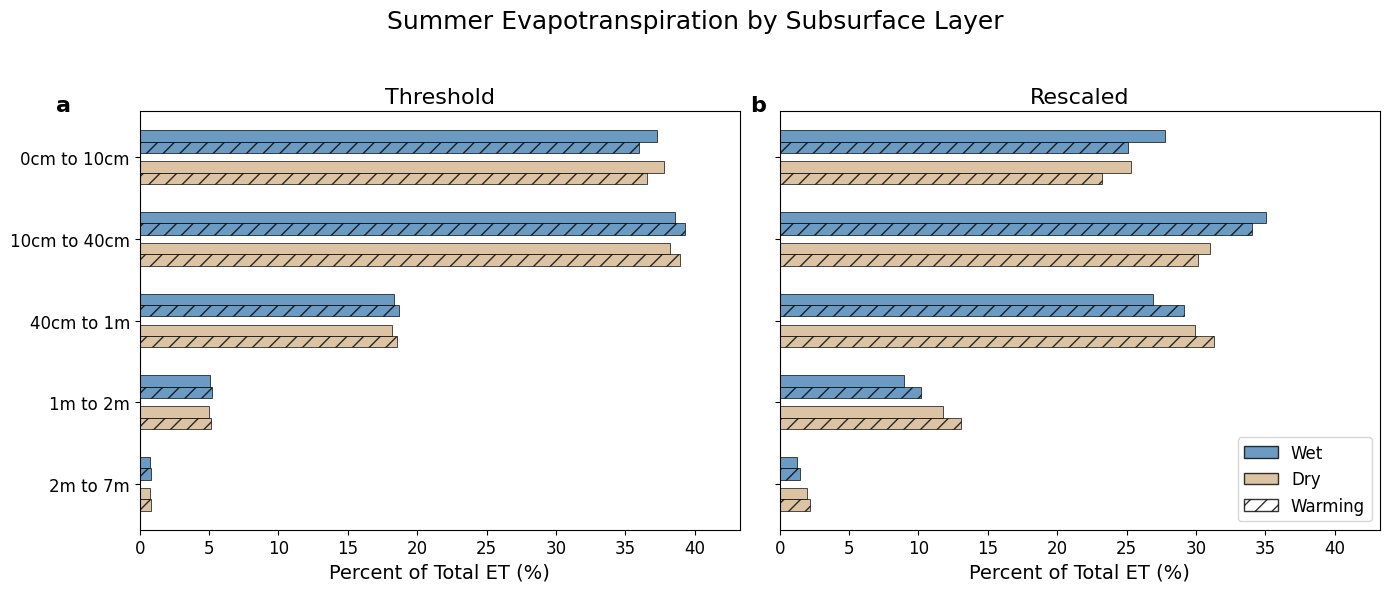

In [11]:
# Rescaled approach
evaptrans_wet_b_mean = np.nanmean(
    np.nansum(evaptrans_wet_b, axis=0),
    axis=(1, 2)
)

evaptrans_wet_w_mean = np.nanmean(
    np.nansum(evaptrans_wet_w, axis=0),
    axis=(1, 2)
)

evaptrans_dry_b_mean = np.nanmean(
    np.nansum(evaptrans_dry_b, axis=0),
    axis=(1, 2)
)

evaptrans_dry_w_mean = np.nanmean(
    np.nansum(evaptrans_dry_w, axis=0),
    axis=(1, 2)
)


# Threshold approach
evaptrans_wet_b_rz0_mean = np.nanmean(
    np.nansum(evaptrans_wet_b_rz0, axis=0),
    axis=(1, 2)
)

evaptrans_wet_w_rz0_mean = np.nanmean(
    np.nansum(evaptrans_wet_w_rz0, axis=0),
    axis=(1, 2)
)

evaptrans_dry_b_rz0_mean = np.nanmean(
    np.nansum(evaptrans_dry_b_rz0, axis=0),
    axis=(1, 2)
)

evaptrans_dry_w_rz0_mean = np.nanmean(
    np.nansum(evaptrans_dry_w_rz0, axis=0),
    axis=(1, 2)
)


# Rescaled
wet_b_top = evaptrans_wet_b_mean[5:][::-1]
wet_w_top = evaptrans_wet_w_mean[5:][::-1]

dry_b_top = evaptrans_dry_b_mean[5:][::-1]
dry_w_top = evaptrans_dry_w_mean[5:][::-1]


# Threshold
wet_b_top_rz0 = evaptrans_wet_b_rz0_mean[5:][::-1]
wet_w_top_rz0 = evaptrans_wet_w_rz0_mean[5:][::-1]

dry_b_top_rz0 = evaptrans_dry_b_rz0_mean[5:][::-1]
dry_w_top_rz0 = evaptrans_dry_w_rz0_mean[5:][::-1]

# Rescaled
wet_b_pct = (
    wet_b_top / np.nansum(wet_b_top) * 100
)

wet_w_pct = (
    wet_w_top / np.nansum(wet_w_top) * 100
)

dry_b_pct = (
    dry_b_top / np.nansum(dry_b_top) * 100
)

dry_w_pct = (
    dry_w_top / np.nansum(dry_w_top) * 100
)


# Threshold
wet_b_pct_rz0 = (
    wet_b_top_rz0 / np.nansum(wet_b_top_rz0) * 100
)

wet_w_pct_rz0 = (
    wet_w_top_rz0 / np.nansum(wet_w_top_rz0) * 100
)

dry_b_pct_rz0 = (
    dry_b_top_rz0 / np.nansum(dry_b_top_rz0) * 100
)

dry_w_pct_rz0 = (
    dry_w_top_rz0 / np.nansum(dry_w_top_rz0) * 100
)

categories = [
    '0cm to 10cm',
    '10cm to 40cm',
    '40cm to 1m',
    '1m to 2m',
    '2m to 7m'
]

y = np.arange(len(categories))

bar_height = 0.14
group_gap = 0.1

wet_b_pos = y - (1.5 * bar_height + group_gap / 2)
wet_w_pos = y - (0.5 * bar_height + group_gap / 2)

dry_b_pos = y + (0.5 * bar_height + group_gap / 2)
dry_w_pos = y + (1.5 * bar_height + group_gap / 2)

wet_color = 'steelblue'
dry_color = 'tan'

all_vals = np.concatenate([
    wet_b_pct_rz0,
    wet_w_pct_rz0,
    dry_b_pct_rz0,
    dry_w_pct_rz0,
    wet_b_pct,
    wet_w_pct,
    dry_b_pct,
    dry_w_pct
])

xmax = np.nanmax(all_vals) * 1.10

# plotting
fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6),
    sharex=True,
    sharey=True
)

fig.suptitle(
    'Summer Evapotranspiration by Subsurface Layer',
    fontsize=18,
    y=0.98
)

ax = axes[0]

ax.text(
    -0.14, 1.04,
    'a',
    transform=ax.transAxes,
    fontsize=16,
    fontweight='bold',
    va='top'
)

ax.barh(
    wet_b_pos,
    wet_b_pct_rz0,
    height=bar_height,
    color=wet_color,
    edgecolor='black',
    linewidth=0.6,
    alpha=0.8
)

ax.barh(
    wet_w_pos,
    wet_w_pct_rz0,
    height=bar_height,
    color=wet_color,
    edgecolor='black',
    linewidth=0.6,
    hatch='//',
    alpha=0.8
)

ax.barh(
    dry_b_pos,
    dry_b_pct_rz0,
    height=bar_height,
    color=dry_color,
    edgecolor='black',
    linewidth=0.6,
    alpha=0.8
)

ax.barh(
    dry_w_pos,
    dry_w_pct_rz0,
    height=bar_height,
    color=dry_color,
    edgecolor='black',
    linewidth=0.6,
    hatch='//',
    alpha=0.8
)

ax.set_title(
    'Threshold',
    fontsize=16
)

ax.set_yticks(y)
ax.set_yticklabels(
    categories,
    fontsize=12
)

ax.invert_yaxis()

ax.set_xlabel(
    'Percent of Total ET (%)',
    fontsize=14
)

ax.tick_params(
    axis='x',
    labelsize=12
)

ax.tick_params(
    axis='y',
    labelsize=12
)

ax.set_xlim(0, xmax)

# rescaled
ax = axes[1]

ax.text(
    -0.05, 1.04,
    'b',
    transform=ax.transAxes,
    fontsize=16,
    fontweight='bold',
    va='top'
)

ax.barh(
    wet_b_pos,
    wet_b_pct,
    height=bar_height,
    color=wet_color,
    edgecolor='black',
    linewidth=0.6,
    alpha=0.8
)

ax.barh(
    wet_w_pos,
    wet_w_pct,
    height=bar_height,
    color=wet_color,
    edgecolor='black',
    linewidth=0.6,
    hatch='//',
    alpha=0.8
)

ax.barh(
    dry_b_pos,
    dry_b_pct,
    height=bar_height,
    color=dry_color,
    edgecolor='black',
    linewidth=0.6,
    alpha=0.8
)

ax.barh(
    dry_w_pos,
    dry_w_pct,
    height=bar_height,
    color=dry_color,
    edgecolor='black',
    linewidth=0.6,
    hatch='//',
    alpha=0.8
)

ax.set_title(
    'Rescaled',
    fontsize=16
)

ax.set_xlabel(
    'Percent of Total ET (%)',
    fontsize=14
)

ax.tick_params(
    axis='x',
    labelsize=12
)

ax.set_xlim(0, xmax)


legend_handles = [
    Patch(
        facecolor=wet_color,
        alpha=0.8,
        edgecolor='black',
        label='Wet'
    ),
    Patch(
        facecolor=dry_color,
        alpha=0.8,
        edgecolor='black',
        label='Dry'
    ),
    Patch(
        facecolor='white',
        alpha=0.8,
        edgecolor='black',
        hatch='//',
        label='Warming'
    )
]

axes[1].legend(
    handles=legend_handles,
    fontsize=12,
    loc='lower right'
)

# for ax in axes:
#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)

plt.tight_layout(
    rect=[0, 0, 1, 0.94]
)

plt.show()

In [12]:
simulations = {
    'Threshold - Wet Baseline': wet_b_pct_rz0,
    'Threshold - Wet Warming':  wet_w_pct_rz0,
    'Threshold - Dry Baseline': dry_b_pct_rz0,
    'Threshold - Dry Warming':  dry_w_pct_rz0,

    'Rescaled - Wet Baseline': wet_b_pct,
    'Rescaled - Wet Warming':  wet_w_pct,
    'Rescaled - Dry Baseline': dry_b_pct,
    'Rescaled - Dry Warming':  dry_w_pct
}


for sim_name, values in simulations.items():

    print(f'\n{sim_name}')
    print('-' * len(sim_name))

    for layer, pct in zip(categories, values):
        print(f'{layer:<15} {pct:6.2f}%')

    print(f'{"TOTAL":<15} {np.nansum(values):6.2f}%')


Threshold - Wet Baseline
------------------------
0cm to 10cm      37.26%
10cm to 40cm     38.57%
40cm to 1m       18.33%
1m to 2m          5.08%
2m to 7m          0.76%
TOTAL           100.00%

Threshold - Wet Warming
-----------------------
0cm to 10cm      36.00%
10cm to 40cm     39.34%
40cm to 1m       18.70%
1m to 2m          5.18%
2m to 7m          0.78%
TOTAL           100.00%

Threshold - Dry Baseline
------------------------
0cm to 10cm      37.77%
10cm to 40cm     38.23%
40cm to 1m       18.21%
1m to 2m          5.03%
2m to 7m          0.76%
TOTAL           100.00%

Threshold - Dry Warming
-----------------------
0cm to 10cm      36.59%
10cm to 40cm     38.94%
40cm to 1m       18.56%
1m to 2m          5.12%
2m to 7m          0.78%
TOTAL           100.00%

Rescaled - Wet Baseline
-----------------------
0cm to 10cm      27.79%
10cm to 40cm     35.02%
40cm to 1m       26.94%
1m to 2m          8.97%
2m to 7m          1.28%
TOTAL           100.00%

Rescaled - Wet Warming
-------

# transpiration - wet vs dry

In [13]:
tran_wet_b_summertotal = np.nansum(
    tran_wet_b[july_start_hr:september_end_hr] * nanmask[0],
    axis=0
) * nanmask[0]

tran_dry_b_summertotal = np.nansum(
    tran_dry_b[july_start_hr:september_end_hr] * nanmask[0],
    axis=0
) * nanmask[0]

tran_wet_b_summertotal_rz0 = np.nansum(
    tran_wet_b_rz0[july_start_hr:september_end_hr] * nanmask[0],
    axis=0
) * nanmask[0]

tran_dry_b_summertotal_rz0 = np.nansum(
    tran_dry_b_rz0[july_start_hr:september_end_hr] * nanmask[0],
    axis=0
) * nanmask[0]

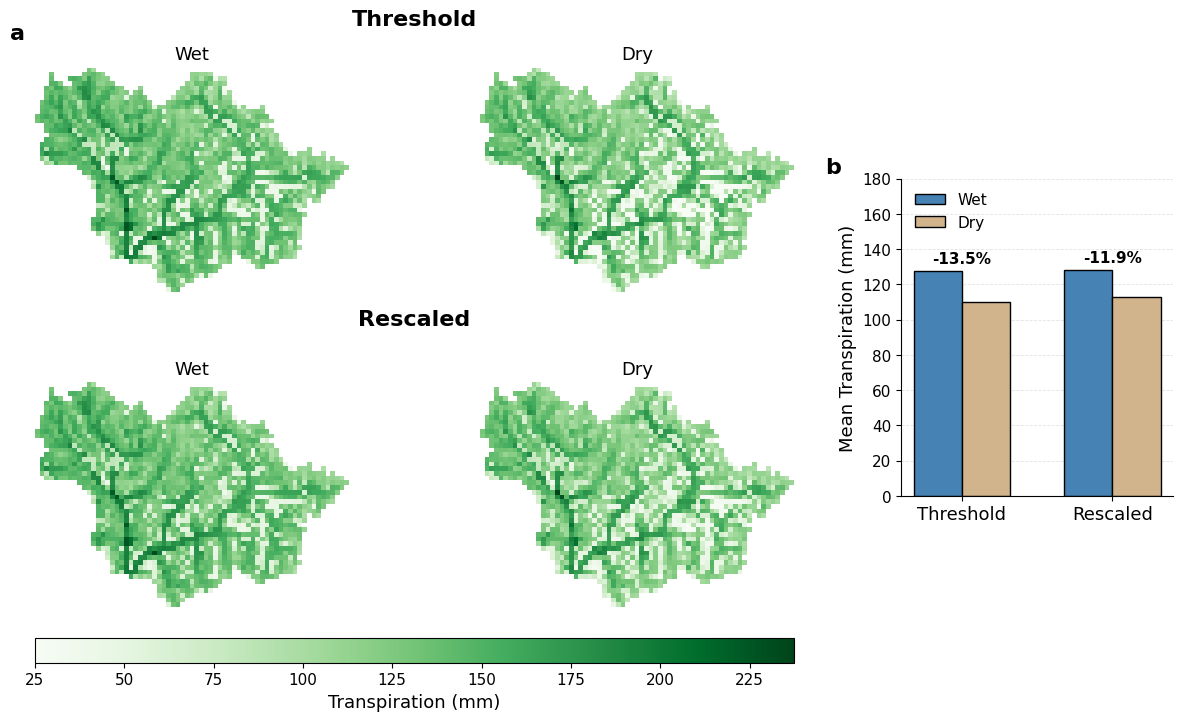

percent diff between dry and wet, threshold =  -13.526969395197062
percent diff between dry and wet, rescaled =  -11.887650670600467

raw diff between dry and wet, threshold =  -17.249693264347428
raw diff between dry and wet, rescaled =  -15.229399985973984

raw threshold - rescaled, wet =  -0.5903463123882204
raw threshold - rescaled, dry =  -2.6106395907616644


In [14]:
maps = [
    tran_wet_b_summertotal_rz0,   # Threshold - Wet
    tran_dry_b_summertotal_rz0,   # Threshold - Dry
    tran_wet_b_summertotal,       # Rescaled - Wet
    tran_dry_b_summertotal        # Rescaled - Dry
]

vmin = np.nanmin([np.nanmin(arr) for arr in maps])
vmax = np.nanmax([np.nanmax(arr) for arr in maps])

norm = colors.Normalize(
    vmin=25,
    vmax=vmax
)

wet_threshold_mean = np.nanmean(
    tran_wet_b_summertotal_rz0
)

dry_threshold_mean = np.nanmean(
    tran_dry_b_summertotal_rz0
)

wet_rescaled_mean = np.nanmean(
    tran_wet_b_summertotal
)

dry_rescaled_mean = np.nanmean(
    tran_dry_b_summertotal
)


threshold_pct_diff = 100 * (
    dry_threshold_mean - wet_threshold_mean
) / wet_threshold_mean

rescaled_pct_diff = 100 * (
    dry_rescaled_mean - wet_rescaled_mean
) / wet_rescaled_mean


fig = plt.figure(figsize=(15, 7))

# gs = fig.add_gridspec(
#     2, 3,
#     width_ratios=[1, 1, 0.75],
#     wspace=0.25,
#     hspace=0.20
# )
gs = fig.add_gridspec(
    2, 3,
    width_ratios=[1, 1, 0.75],
    wspace=0.25,
    hspace=0.40   # increased from 0.20
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])


# Make bar chart shorter
bar_gs = gs[:, 2].subgridspec(
    3, 1,
    height_ratios=[0.5, 2.0, 0.5]
)

ax_bar = fig.add_subplot(
    bar_gs[1, 0]
)

# Threshold - Wet
im1 = ax1.imshow(
    np.ma.masked_invalid(
        tran_wet_b_summertotal_rz0
    ),
    origin='lower',
    cmap='Greens',
    norm=norm
)

# Threshold - Dry
im2 = ax2.imshow(
    np.ma.masked_invalid(
        tran_dry_b_summertotal_rz0
    ),
    origin='lower',
    cmap='Greens',
    norm=norm
)

# Rescaled - Wet
im3 = ax3.imshow(
    np.ma.masked_invalid(
        tran_wet_b_summertotal
    ),
    origin='lower',
    cmap='Greens',
    norm=norm
)

# Rescaled - Dry
im4 = ax4.imshow(
    np.ma.masked_invalid(
        tran_dry_b_summertotal
    ),
    origin='lower',
    cmap='Greens',
    norm=norm
)

ax1.set_title(
    'Wet',
    fontsize=13
)

ax2.set_title(
    'Dry',
    fontsize=13
)

ax3.set_title(
    'Wet',
    fontsize=13
)

ax4.set_title(
    'Dry',
    fontsize=13
)


for ax in [ax1, ax2, ax3, ax4]:
    ax.axis('off')

map_center = (
    ax1.get_position().x0
    + ax2.get_position().x1
) / 2

ax1.text(
    -1.5, 2.6,
    'a',
    transform=ax.transAxes,
    fontsize=16,
    fontweight='bold',
    va='top'
)

fig.text(
    map_center,
    ax1.get_position().y1 + 0.055,
    'Threshold',
    ha='center',
    va='bottom',
    fontsize=16,
    fontweight='bold'
)

fig.text(
    map_center,
    ax3.get_position().y1 + 0.075,  # increased from 0.025
    'Rescaled',
    ha='center',
    va='bottom',
    fontsize=16,
    fontweight='bold'
)


left = ax1.get_position().x0
right = ax2.get_position().x1
bottom = ax3.get_position().y0

cax = fig.add_axes([
    left,
    bottom - 0.08,
    right - left,
    0.035
])

cbar = fig.colorbar(
    im1,
    cax=cax,
    orientation='horizontal'
)

cbar.set_label(
    'Transpiration (mm)',
    fontsize=13
)

cbar.ax.tick_params(
    labelsize=11
)


x = np.array([0, 1])

width = 0.32


wet_vals = [
    wet_threshold_mean,
    wet_rescaled_mean
]

dry_vals = [
    dry_threshold_mean,
    dry_rescaled_mean
]


bars_wet = ax_bar.bar(
    x - width/2,
    wet_vals,
    width=width,
    color='steelblue',
    edgecolor='black',
    label='Wet'
)


bars_dry = ax_bar.bar(
    x + width/2,
    dry_vals,
    width=width,
    color='tan',
    edgecolor='black',
    label='Dry'
)

ax_bar.set_xticks(x)

ax_bar.set_xticklabels(
    ['Threshold', 'Rescaled'],
    fontsize=13
)

ax_bar.set_ylabel(
    'Mean Transpiration (mm)',
    fontsize=13
)

ax_bar.tick_params(
    axis='y',
    labelsize=11
)

ax_bar.legend(
    frameon=False,
    fontsize=11, 
    loc = 'upper left'
)

ax_bar.spines['top'].set_visible(False)
ax_bar.spines['right'].set_visible(False)

# ax_bar.yaxis.set_major_locator(MultipleLocator(10))

ax_bar.grid(
    axis='y',
    linestyle='--',
    linewidth=0.6,
    alpha=0.35
)

ax_bar.text(
    1.1, 2,
    'b',
    transform=ax.transAxes,
    fontsize=16,
    fontweight='bold',
    va='top'
)

ax_bar.set_axisbelow(True)

pct_diffs = [
    threshold_pct_diff,
    rescaled_pct_diff
]

for i, pct in enumerate(pct_diffs):

    pair_max = max(
        wet_vals[i],
        dry_vals[i]
    )

    ax_bar.text(
        x[i],
        pair_max + 0.02 * max(wet_vals + dry_vals),
        f'{pct:+.1f}%',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )


bar_max = max(
    wet_vals + dry_vals
)


ax_bar.set_ylim(0,180)

plt.show()


print(
    'percent diff between dry and wet, threshold = ',
    threshold_pct_diff
)

print(
    'percent diff between dry and wet, rescaled = ',
    rescaled_pct_diff
)

print('')

print(
    'raw diff between dry and wet, threshold = ',
    dry_threshold_mean - wet_threshold_mean
)

print(
    'raw diff between dry and wet, rescaled = ',
    dry_rescaled_mean - wet_rescaled_mean
)

print('')

print(
    'raw threshold - rescaled, wet = ',
    wet_threshold_mean - wet_rescaled_mean
)

print(
    'raw threshold - rescaled, dry = ',
    dry_threshold_mean - dry_rescaled_mean
)



# transpiration - warming effects

In [15]:
tran_wet_w_summertotal = np.nansum(tran_wet_w[july_start_hr:september_end_hr, :, :] *nanmask[0], axis = 0)*nanmask[0]
tran_dry_w_summertotal = np.nansum(tran_dry_w[july_start_hr:september_end_hr, :, :] *nanmask[0], axis = 0)*nanmask[0]

tran_wet_w_summertotal_rz0 = np.nansum(tran_wet_w_rz0[july_start_hr:september_end_hr, :, :] *nanmask[0], axis = 0)*nanmask[0]
tran_dry_w_summertotal_rz0 = np.nansum(tran_dry_w_rz0[july_start_hr:september_end_hr, :, :] *nanmask[0], axis = 0)*nanmask[0]

In [16]:
twarm_tbaseline_wet = tran_wet_w_summertotal - tran_wet_b_summertotal
twarm_tbaseline_dry = tran_dry_w_summertotal - tran_dry_b_summertotal

twarm_tbaseline_wet_rz0 = tran_wet_w_summertotal_rz0 - tran_wet_b_summertotal_rz0
twarm_tbaseline_dry_rz0 = tran_dry_w_summertotal_rz0 - tran_dry_b_summertotal_rz0

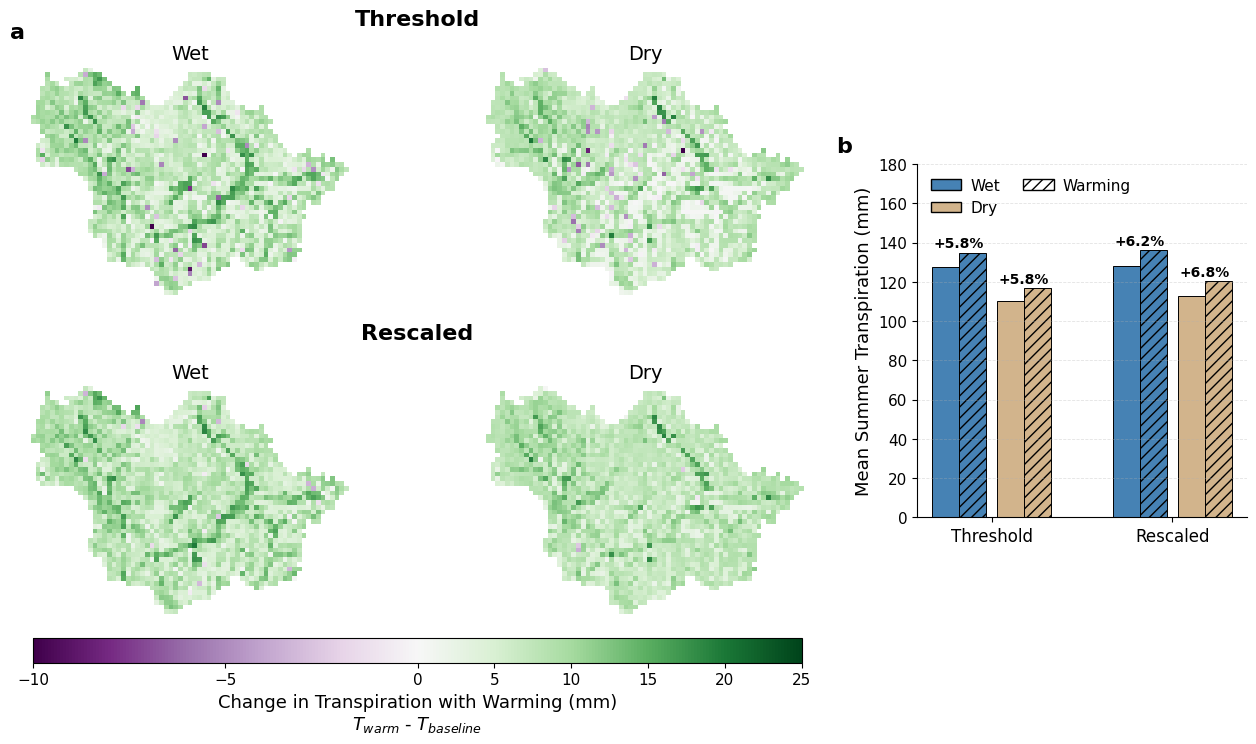

warming diff wet threshold =  7.37224201063114
warming diff dry threshold =  6.444668393276302

warming diff wet rescaled =  7.941112671495972
warming diff dry rescaled =  7.666638498053473


In [17]:
norm = colors.TwoSlopeNorm(
    vmin=-10,
    vcenter=0,
    vmax=25
)

wet_threshold_baseline = np.nanmean(
    tran_wet_b_summertotal_rz0
)

wet_threshold_warm = np.nanmean(
    tran_wet_w_summertotal_rz0
)

dry_threshold_baseline = np.nanmean(
    tran_dry_b_summertotal_rz0
)

dry_threshold_warm = np.nanmean(
    tran_dry_w_summertotal_rz0
)


# Rescaled approach
wet_rescaled_baseline = np.nanmean(
    tran_wet_b_summertotal
)

wet_rescaled_warm = np.nanmean(
    tran_wet_w_summertotal
)

dry_rescaled_baseline = np.nanmean(
    tran_dry_b_summertotal
)

dry_rescaled_warm = np.nanmean(
    tran_dry_w_summertotal
)

wet_threshold_pct = 100 * (
    wet_threshold_warm - wet_threshold_baseline
) / wet_threshold_baseline

dry_threshold_pct = 100 * (
    dry_threshold_warm - dry_threshold_baseline
) / dry_threshold_baseline

wet_rescaled_pct = 100 * (
    wet_rescaled_warm - wet_rescaled_baseline
) / wet_rescaled_baseline

dry_rescaled_pct = 100 * (
    dry_rescaled_warm - dry_rescaled_baseline
) / dry_rescaled_baseline


fig = plt.figure(figsize=(16, 7))

gs = fig.add_gridspec(
    2, 3,
    width_ratios=[1, 1, 0.9],
    wspace=0.25,
    hspace=0.40
)

# Maps
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# Shorter bar plot on right
bar_gs = gs[:, 2].subgridspec(
    3, 1,
    height_ratios=[0.4, 2.2, 0.4]
)

ax_bar = fig.add_subplot(bar_gs[1, 0])


im1 = ax1.imshow(
    np.ma.masked_array(
        twarm_tbaseline_wet_rz0,
        surf_mask == 0
    ),
    norm=norm,
    origin='lower',
    cmap='PRGn'
)

# Threshold - Dry
im2 = ax2.imshow(
    np.ma.masked_array(
        twarm_tbaseline_dry_rz0,
        surf_mask == 0
    ),
    norm=norm,
    origin='lower',
    cmap='PRGn'
)

# Rescaled - Wet
im3 = ax3.imshow(
    np.ma.masked_array(
        twarm_tbaseline_wet,
        surf_mask == 0
    ),
    norm=norm,
    origin='lower',
    cmap='PRGn'
)

# Rescaled - Dry
im4 = ax4.imshow(
    np.ma.masked_array(
        twarm_tbaseline_dry,
        surf_mask == 0
    ),
    norm=norm,
    origin='lower',
    cmap='PRGn'
)

ax1.set_title(
    'Wet',
    fontsize=14
)

ax2.set_title(
    'Dry',
    fontsize=14
)

ax3.set_title(
    'Wet',
    fontsize=14
)

ax4.set_title(
    'Dry',
    fontsize=14
)

for ax in [ax1, ax2, ax3, ax4]:
    ax.axis('off')

map_center = (
    ax1.get_position().x0
    + ax2.get_position().x1
) / 2

ax1.text(
    -1.5, 2.6,
    'a',
    transform=ax.transAxes,
    fontsize=16,
    fontweight='bold',
    va='top'
)

fig.text(
    map_center,
    ax1.get_position().y1 + 0.055,
    'Threshold',
    ha='center',
    va='bottom',
    fontsize=16,
    fontweight='bold'
)


fig.text(
    map_center,
    ax3.get_position().y1 + 0.055,
    'Rescaled',
    ha='center',
    va='bottom',
    fontsize=16,
    fontweight='bold'
)


left = ax1.get_position().x0
right = ax2.get_position().x1
bottom = ax3.get_position().y0

cax = fig.add_axes([
    left,
    bottom - 0.08,
    right - left,
    0.035
])

cbar = fig.colorbar(
    im1,
    cax=cax,
    orientation='horizontal'
)

cbar.set_label(
    'Change in Transpiration with Warming (mm)\n$T_{warm}$ - $T_{baseline}$',
    fontsize=13
)

cbar.ax.tick_params(
    labelsize=11
)

x = np.array([0, 1])

width = 0.15
group_gap = 0.06

wet_color = 'steelblue'
dry_color = 'tan'


wet_baseline_pos = (
    x - 1.5 * width - group_gap / 2
)

wet_warm_pos = (
    x - 0.5 * width - group_gap / 2
)

dry_baseline_pos = (
    x + 0.5 * width + group_gap / 2
)

dry_warm_pos = (
    x + 1.5 * width + group_gap / 2
)

wet_baseline_vals = [
    wet_threshold_baseline,
    wet_rescaled_baseline
]

wet_warm_vals = [
    wet_threshold_warm,
    wet_rescaled_warm
]

dry_baseline_vals = [
    dry_threshold_baseline,
    dry_rescaled_baseline
]

dry_warm_vals = [
    dry_threshold_warm,
    dry_rescaled_warm
]

# Wet baseline
ax_bar.bar(
    wet_baseline_pos,
    wet_baseline_vals,
    width=width,
    color=wet_color,
    edgecolor='black',
    linewidth=0.7
)

# Wet warming
ax_bar.bar(
    wet_warm_pos,
    wet_warm_vals,
    width=width,
    color=wet_color,
    edgecolor='black',
    linewidth=0.7,
    hatch='///'
)

# Dry baseline
ax_bar.bar(
    dry_baseline_pos,
    dry_baseline_vals,
    width=width,
    color=dry_color,
    edgecolor='black',
    linewidth=0.7
)

# Dry warming
ax_bar.bar(
    dry_warm_pos,
    dry_warm_vals,
    width=width,
    color=dry_color,
    edgecolor='black',
    linewidth=0.7,
    hatch='///'
)

ax_bar.set_xticks(x)

ax_bar.set_xticklabels(
    ['Threshold', 'Rescaled'],
    fontsize=13
)

ax_bar.set_ylabel(
    'Mean Summer Transpiration (mm)',
    fontsize=13
)

ax_bar.tick_params(
    axis='y',
    labelsize=11
)

ax_bar.tick_params(
    axis='x',
    labelsize=12
)

ax_bar.spines['top'].set_visible(False)
ax_bar.spines['right'].set_visible(False)

wet_pcts = [
    wet_threshold_pct,
    wet_rescaled_pct
]

dry_pcts = [
    dry_threshold_pct,
    dry_rescaled_pct
]


all_bar_vals = (
    wet_baseline_vals
    + wet_warm_vals
    + dry_baseline_vals
    + dry_warm_vals
)

bar_max = max(all_bar_vals)
bar_min = min(all_bar_vals)

bar_range = bar_max - bar_min

if bar_range == 0:
    bar_range = 1


for i in range(2):

    wet_center = (
        wet_baseline_pos[i]
        + wet_warm_pos[i]
    ) / 2

    dry_center = (
        dry_baseline_pos[i]
        + dry_warm_pos[i]
    ) / 2


    wet_top = max(
        wet_baseline_vals[i],
        wet_warm_vals[i]
    )

    dry_top = max(
        dry_baseline_vals[i],
        dry_warm_vals[i]
    )


    ax_bar.text(
        wet_center,
        wet_top + 0.04 * bar_range,
        f'{wet_pcts[i]:+.1f}%',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )


    ax_bar.text(
        dry_center,
        dry_top + 0.04 * bar_range,
        f'{dry_pcts[i]:+.1f}%',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

ax_bar.grid(
    axis='y',
    linestyle='--',
    linewidth=0.6,
    alpha=0.35
)


ax_bar.set_ylim(0,180)
ax_bar.text(
    1.1, 2.1,
    'b',
    transform=ax.transAxes,
    fontsize=16,
    fontweight='bold',
    va='top'
)

legend_handles = [
    Patch(
        facecolor=wet_color,
        edgecolor='black',
        label='Wet'
    ),
    Patch(
        facecolor=dry_color,
        edgecolor='black',
        label='Dry'
    ),
    Patch(
        facecolor='white',
        edgecolor='black',
        hatch='///',
        label='Warming'
    )
]

ax_bar.legend(
    handles=legend_handles,
    frameon=False,
    fontsize=11,
    loc='upper left',
    ncol=2,
    columnspacing=1.5,
    handletextpad=0.6
)


plt.subplots_adjust(
    bottom=0.1
)

plt.show()


print('warming diff wet threshold = ', wet_threshold_warm - wet_threshold_baseline)
print('warming diff dry threshold = ', dry_threshold_warm - dry_threshold_baseline)

print('')

print('warming diff wet rescaled = ', wet_rescaled_warm - wet_rescaled_baseline)
print('warming diff dry rescaled = ', dry_rescaled_warm - dry_rescaled_baseline)


# subsurface storage

In [18]:
# ending subsurface storage 
storage_wet_b_end = np.nansum(storage_wet_b[-1] * nanmask[0], axis = 0) * 1000/ (dx * dy) * nanmask[0]
storage_wet_w_end = np.nansum(storage_wet_w[-1] * nanmask[0], axis = 0) * 1000 / (dx * dy)* nanmask[0]

storage_dry_b_end = np.nansum(storage_dry_b[-1] * nanmask[0], axis = 0) * 1000/ (dx * dy)* nanmask[0]
storage_dry_w_end = np.nansum(storage_dry_w[-1] * nanmask[0], axis = 0) * 1000 / (dx * dy)* nanmask[0]


storage_wet_b_end_rz0 = np.nansum(storage_wet_b_rz0[-1] * nanmask[0], axis = 0) * 1000/ (dx * dy)* nanmask[0]
storage_wet_w_end_rz0 = np.nansum(storage_wet_w_rz0[-1] * nanmask[0], axis = 0) * 1000 / (dx * dy)* nanmask[0]

storage_dry_b_end_rz0 = np.nansum(storage_dry_b_rz0[-1] * nanmask[0], axis = 0) * 1000/ (dx * dy)* nanmask[0]
storage_dry_w_end_rz0 = np.nansum(storage_dry_w_rz0[-1] * nanmask[0], axis = 0) * 1000 / (dx * dy)* nanmask[0]


In [19]:
storage_wet_b_start = np.nansum(storage_wet_b[0] * nanmask[0], axis = 0) * 1000/ (dx * dy) * nanmask[0]
storage_wet_w_start = np.nansum(storage_wet_w[0] * nanmask[0], axis = 0) * 1000 / (dx * dy)* nanmask[0]

storage_dry_b_start = np.nansum(storage_dry_b[0] * nanmask[0], axis = 0) * 1000/ (dx * dy)* nanmask[0]
storage_dry_w_start = np.nansum(storage_dry_w[0] * nanmask[0], axis = 0) * 1000 / (dx * dy)* nanmask[0]


storage_wet_b_start_rz0 = np.nansum(storage_wet_b_rz0[0] * nanmask[0], axis = 0) * 1000/ (dx * dy)* nanmask[0]
storage_wet_w_start_rz0 = np.nansum(storage_wet_w_rz0[0] * nanmask[0], axis = 0) * 1000 / (dx * dy)* nanmask[0]

storage_dry_b_start_rz0 = np.nansum(storage_dry_b_rz0[0] * nanmask[0], axis = 0) * 1000/ (dx * dy)* nanmask[0]
storage_dry_w_start_rz0 = np.nansum(storage_dry_w_rz0[0] * nanmask[0], axis = 0) * 1000 / (dx * dy)* nanmask[0]


In [20]:
storage_dry_b_end_rz0.shape

(48, 67)

### change over the entire WY

In [21]:
print('wet warm change', np.nanmean(storage_wet_w_end*nanmask[0]) - np.nanmean(storage_wet_w_start*nanmask[0]))
print('wet baseline change', np.nanmean(storage_wet_b_end*nanmask[0]) - np.nanmean(storage_wet_b_start*nanmask[0]))
print('')
print('dry warm change', np.nanmean(storage_dry_w_end*nanmask[0]) - np.nanmean(storage_dry_w_start*nanmask[0]))
print('dry baseline change', np.nanmean(storage_dry_b_end*nanmask[0]) - np.nanmean(storage_dry_b_start*nanmask[0]))
print('')
print('wet warm change, threshold', np.nanmean(storage_wet_w_end_rz0*nanmask[0]) - np.nanmean(storage_wet_w_start_rz0*nanmask[0]))
print('wet baseline change, threshold', np.nanmean(storage_wet_b_end_rz0*nanmask[0]) - np.nanmean(storage_wet_b_start_rz0*nanmask[0]))
print('')
print('dry warm change, threshold', np.nanmean(storage_dry_w_end_rz0*nanmask[0]) - np.nanmean(storage_dry_w_start_rz0*nanmask[0]))
print('dry baseline change, threshold', np.nanmean(storage_dry_b_end_rz0*nanmask[0]) - np.nanmean(storage_dry_b_start_rz0*nanmask[0]))



wet warm change -1.1076134150862345
wet baseline change 18.517685354181594

dry warm change -94.48070857278435
dry baseline change -76.92907082902457

wet warm change, threshold 3.5161681647114165
wet baseline change, threshold 22.712277087466646

dry warm change, threshold -84.46574751216394
dry baseline change, threshold -68.28791576193544


In [22]:
# change in ending subsurface storage with warming
storage_wet_change = storage_wet_w_end*nanmask[0] - storage_wet_b_end*nanmask[0]

storage_dry_change = storage_dry_w_end*nanmask[0] - storage_dry_b_end*nanmask[0]

storage_wet_change_rz0 = storage_wet_w_end_rz0*nanmask[0] - storage_wet_b_end_rz0*nanmask[0]

storage_dry_change_rz0 = storage_dry_w_end_rz0*nanmask[0] - storage_dry_b_end_rz0*nanmask[0]


## effect on summer storage change

In [23]:
# starting subsurface storage 
storage_wet_b_start = np.nansum(storage_wet_b[july_start_hr] * nanmask[0], axis = 0) * 1000/ (dx * dy) * nanmask[0]
storage_wet_w_start = np.nansum(storage_wet_w[july_start_hr] * nanmask[0], axis = 0) * 1000 / (dx * dy)* nanmask[0]

storage_dry_b_start = np.nansum(storage_dry_b[july_start_hr] * nanmask[0], axis = 0) * 1000/ (dx * dy)* nanmask[0]
storage_dry_w_start = np.nansum(storage_dry_w[july_start_hr] * nanmask[0], axis = 0) * 1000 / (dx * dy)* nanmask[0]


storage_wet_b_start_rz0 = np.nansum(storage_wet_b_rz0[july_start_hr] * nanmask[0], axis = 0) * 1000/ (dx * dy)* nanmask[0]
storage_wet_w_start_rz0 = np.nansum(storage_wet_w_rz0[july_start_hr] * nanmask[0], axis = 0) * 1000 / (dx * dy)* nanmask[0]

storage_dry_b_start_rz0 = np.nansum(storage_dry_b_rz0[july_start_hr] * nanmask[0], axis = 0) * 1000/ (dx * dy)* nanmask[0]
storage_dry_w_start_rz0 = np.nansum(storage_dry_w_rz0[july_start_hr] * nanmask[0], axis = 0) * 1000 / (dx * dy)* nanmask[0]

In [24]:
# summer change in storage
storage_wet_w_summerchange = storage_wet_w_end*nanmask[0] - storage_wet_w_start*nanmask[0]
storage_dry_w_summerchange = storage_dry_w_end*nanmask[0] - storage_dry_w_start*nanmask[0]

storage_wet_b_summerchange = storage_wet_b_end*nanmask[0] - storage_wet_b_start*nanmask[0]
storage_dry_b_summerchange = storage_dry_b_end*nanmask[0] - storage_dry_b_start*nanmask[0]


storage_wet_w_summerchange_rz0  = storage_wet_w_end_rz0 *nanmask[0] - storage_wet_w_start_rz0 *nanmask[0]
storage_dry_w_summerchange_rz0  = storage_dry_w_end_rz0 *nanmask[0] - storage_dry_w_start_rz0 *nanmask[0]

storage_wet_b_summerchange_rz0  = storage_wet_b_end_rz0 *nanmask[0] - storage_wet_b_start_rz0 *nanmask[0]
storage_dry_b_summerchange_rz0  = storage_dry_b_end_rz0 *nanmask[0] - storage_dry_b_start_rz0 *nanmask[0]

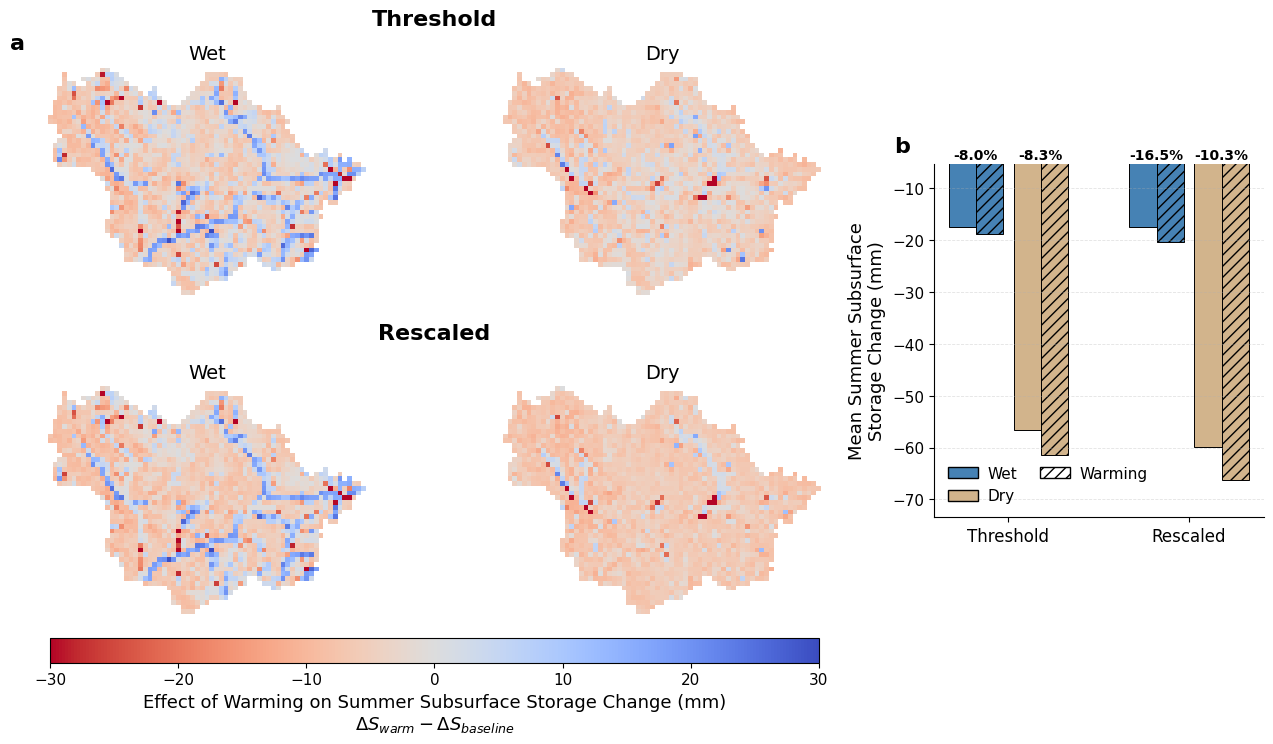

THRESHOLD
Wet baseline summer change =  -17.465756385939454
Wet warm summer change     =  -18.86981231190255
Wet warming effect          =  -1.404055925963096
Wet percent change          =  -8.038907075867668

Dry baseline summer change =  -56.69464832889349
Dry warm summer change     =  -61.408170113677585
Dry warming effect          =  -4.713521784784092
Dry percent change          =  -8.313874278644962

RESCALED
Wet baseline summer change =  -17.465756385939454
Wet warm summer change     =  -20.34739766973375
Wet warming effect          =  -2.881641283794295
Wet percent change          =  -16.49880612164107

Dry baseline summer change =  -59.96631264688117
Dry warm summer change     =  -66.15328474129832
Dry warming effect          =  -6.1869720944171505
Dry percent change          =  -10.317412929572438


In [25]:
storage_wet_warming_effect = (
    storage_wet_w_summerchange
    - storage_wet_b_summerchange
)

storage_dry_warming_effect = (
    storage_dry_w_summerchange
    - storage_dry_b_summerchange
)

storage_wet_warming_effect_rz0 = (
    storage_wet_w_summerchange_rz0
    - storage_wet_b_summerchange_rz0
)

storage_dry_warming_effect_rz0 = (
    storage_dry_w_summerchange_rz0
    - storage_dry_b_summerchange_rz0
)

all_maps = [
    storage_wet_warming_effect_rz0,
    storage_dry_warming_effect_rz0,
    storage_wet_warming_effect,
    storage_dry_warming_effect
]

map_absmax = max(
    np.nanmax(np.abs(arr))
    for arr in all_maps
)

norm = colors.TwoSlopeNorm(
    vmin=-30,#-map_absmax,
    vcenter=0,
    vmax=30#map_absmax
)

wet_threshold_baseline = np.nanmean(
    storage_wet_b_summerchange
    * np.where(nanmask[0] == 0, np.nan, 1)
)

wet_threshold_warm = np.nanmean(
    storage_wet_w_summerchange_rz0
    * np.where(nanmask[0] == 0, np.nan, 1)
)

dry_threshold_baseline = np.nanmean(
    storage_dry_b_summerchange_rz0
    * np.where(nanmask[0] == 0, np.nan, 1)
)

dry_threshold_warm = np.nanmean(
    storage_dry_w_summerchange_rz0
    * np.where(nanmask[0] == 0, np.nan, 1)
)

wet_rescaled_baseline = np.nanmean(
    storage_wet_b_summerchange
    * np.where(nanmask[0] == 0, np.nan, 1)
)

wet_rescaled_warm = np.nanmean(
    storage_wet_w_summerchange
    * np.where(nanmask[0] == 0, np.nan, 1)
)

dry_rescaled_baseline = np.nanmean(
    storage_dry_b_summerchange
    * np.where(nanmask[0] == 0, np.nan, 1)
)

dry_rescaled_warm = np.nanmean(
    storage_dry_w_summerchange
    * np.where(nanmask[0] == 0, np.nan, 1)
)


# percent change
wet_threshold_pct = 100 * (
    wet_threshold_warm - wet_threshold_baseline
) / np.abs(wet_threshold_baseline)

dry_threshold_pct = 100 * (
    dry_threshold_warm - dry_threshold_baseline
) / np.abs(dry_threshold_baseline)

wet_rescaled_pct = 100 * (
    wet_rescaled_warm - wet_rescaled_baseline
) / np.abs(wet_rescaled_baseline)

dry_rescaled_pct = 100 * (
    dry_rescaled_warm - dry_rescaled_baseline
) / np.abs(dry_rescaled_baseline)


#plotting
fig = plt.figure(figsize=(16, 7))

gs = fig.add_gridspec(
    2, 3,
    width_ratios=[1, 1, 0.9],
    wspace=0.25,
    hspace=0.40
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# Shorter bar plot on right
bar_gs = gs[:, 2].subgridspec(
    3, 1,
    height_ratios=[0.4, 2.2, 0.4]
)

ax_bar = fig.add_subplot(bar_gs[1, 0])

# Threshold - Wet
im1 = ax1.imshow(
    np.ma.masked_array(
        storage_wet_warming_effect_rz0,
        surf_mask == 0
    ),
    norm=norm,
    origin='lower',
    cmap='coolwarm_r'
)

# Threshold - Dry
im2 = ax2.imshow(
    np.ma.masked_array(
        storage_dry_warming_effect_rz0,
        surf_mask == 0
    ),
    norm=norm,
    origin='lower',
    cmap='coolwarm_r'
)

# Rescaled - Wet
im3 = ax3.imshow(
    np.ma.masked_array(
        storage_wet_warming_effect,
        surf_mask == 0
    ),
    norm=norm,
    origin='lower',
    cmap='coolwarm_r'
)

# Rescaled - Dry
im4 = ax4.imshow(
    np.ma.masked_array(
        storage_dry_warming_effect,
        surf_mask == 0
    ),
    norm=norm,
    origin='lower',
    cmap='coolwarm_r'
)

ax1.set_title('Wet', fontsize=14)
ax2.set_title('Dry', fontsize=14)
ax3.set_title('Wet', fontsize=14)
ax4.set_title('Dry', fontsize=14)

for ax in [ax1, ax2, ax3, ax4]:
    ax.axis('off')

map_center = (
    ax1.get_position().x0
    + ax2.get_position().x1
) / 2


ax1.text(
    -0.12, 1.15,
    'a',
    transform=ax1.transAxes,
    fontsize=16,
    fontweight='bold',
    va='top'
)


fig.text(
    map_center,
    ax1.get_position().y1 + 0.055,
    'Threshold',
    ha='center',
    va='bottom',
    fontsize=16,
    fontweight='bold'
)


fig.text(
    map_center,
    ax3.get_position().y1 + 0.055,
    'Rescaled',
    ha='center',
    va='bottom',
    fontsize=16,
    fontweight='bold'
)


# colorbar
left = ax1.get_position().x0
right = ax2.get_position().x1
bottom = ax3.get_position().y0

cax = fig.add_axes([
    left,
    bottom - 0.08,
    right - left,
    0.035
])

cbar = fig.colorbar(
    im1,
    cax=cax,
    orientation='horizontal'
)

cbar.set_label(
    'Effect of Warming on Summer Subsurface Storage Change (mm)\n'
    '$\\Delta S_{warm} - \\Delta S_{baseline}$',
    fontsize=13
)

cbar.ax.tick_params(
    labelsize=11
)

x = np.array([0, 1])

width = 0.15
group_gap = 0.06

wet_color = 'steelblue'
dry_color = 'tan'


wet_baseline_pos = (
    x - 1.5 * width - group_gap / 2
)

wet_warm_pos = (
    x - 0.5 * width - group_gap / 2
)

dry_baseline_pos = (
    x + 0.5 * width + group_gap / 2
)

dry_warm_pos = (
    x + 1.5 * width + group_gap / 2
)


wet_baseline_vals = [
    wet_threshold_baseline,
    wet_rescaled_baseline
]

wet_warm_vals = [
    wet_threshold_warm,
    wet_rescaled_warm
]

dry_baseline_vals = [
    dry_threshold_baseline,
    dry_rescaled_baseline
]

dry_warm_vals = [
    dry_threshold_warm,
    dry_rescaled_warm
]

# Wet baseline
ax_bar.bar(
    wet_baseline_pos,
    wet_baseline_vals,
    width=width,
    color=wet_color,
    edgecolor='black',
    linewidth=0.7
)

# Wet warming
ax_bar.bar(
    wet_warm_pos,
    wet_warm_vals,
    width=width,
    color=wet_color,
    edgecolor='black',
    linewidth=0.7,
    hatch='///'
)

# Dry baseline
ax_bar.bar(
    dry_baseline_pos,
    dry_baseline_vals,
    width=width,
    color=dry_color,
    edgecolor='black',
    linewidth=0.7
)

# Dry warming
ax_bar.bar(
    dry_warm_pos,
    dry_warm_vals,
    width=width,
    color=dry_color,
    edgecolor='black',
    linewidth=0.7,
    hatch='///'
)

ax_bar.grid(
    axis='y',
    linestyle='--',
    linewidth=0.6,
    alpha=0.35
)

ax_bar.set_xticks(x)

ax_bar.set_xticklabels(
    ['Threshold', 'Rescaled'],
    fontsize=13
)

ax_bar.set_ylabel(
    'Mean Summer Subsurface\nStorage Change (mm)',
    fontsize=13
)

ax_bar.tick_params(
    axis='y',
    labelsize=11
)

ax_bar.tick_params(
    axis='x',
    labelsize=12
)

ax_bar.axhline(
    0,
    color='black',
    linewidth=0.8
)

ax_bar.spines['top'].set_visible(False)
ax_bar.spines['right'].set_visible(False)

wet_pcts = [
    wet_threshold_pct,
    wet_rescaled_pct
]

dry_pcts = [
    dry_threshold_pct,
    dry_rescaled_pct
]


all_bar_vals = (
    wet_baseline_vals
    + wet_warm_vals
    + dry_baseline_vals
    + dry_warm_vals
)

bar_max = max(all_bar_vals)
bar_min = min(all_bar_vals)

bar_range = bar_max - bar_min

if bar_range == 0:
    bar_range = 1


for i in range(2):

    wet_center = (
        wet_baseline_pos[i]
        + wet_warm_pos[i]
    ) / 2

    dry_center = (
        dry_baseline_pos[i]
        + dry_warm_pos[i]
    ) / 2


    # Put labels above the higher bar
    wet_top = max(
        wet_baseline_vals[i],
        wet_warm_vals[i]
    )

    dry_top = max(
        dry_baseline_vals[i],
        dry_warm_vals[i]
    )


    ax_bar.text(
        wet_center,
        -5,#wet_top + 0.05 * bar_range,
        f'{wet_pcts[i]:+.1f}%',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )


    ax_bar.text(
        dry_center,
        -5,#dry_top + 0.05 * bar_range,
        f'{dry_pcts[i]:+.1f}%',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )


ax_bar.set_ylim(
    bar_min - 0.15 * bar_range,
    bar_max + 0.25 * bar_range
)


ax_bar.text(
    -0.12, 1.08,
    'b',
    transform=ax_bar.transAxes,
    fontsize=16,
    fontweight='bold',
    va='top'
)

legend_handles = [
    Patch(
        facecolor=wet_color,
        edgecolor='black',
        label='Wet'
    ),
    Patch(
        facecolor=dry_color,
        edgecolor='black',
        label='Dry'
    ),
    Patch(
        facecolor='white',
        edgecolor='black',
        hatch='///',
        label='Warming'
    )
]

ax_bar.legend(
    handles=legend_handles,
    frameon=False,
    fontsize=11,
    loc='lower left',
    ncol=2,
    columnspacing=1.5,
    handletextpad=0.6
)

plt.subplots_adjust(
    bottom=0.1
)

plt.show()

print('THRESHOLD')
print('Wet baseline summer change = ', wet_threshold_baseline)
print('Wet warm summer change     = ', wet_threshold_warm)
print(
    'Wet warming effect          = ',
    wet_threshold_warm - wet_threshold_baseline
)
print('Wet percent change          = ', wet_threshold_pct)

print('')

print('Dry baseline summer change = ', dry_threshold_baseline)
print('Dry warm summer change     = ', dry_threshold_warm)
print(
    'Dry warming effect          = ',
    dry_threshold_warm - dry_threshold_baseline
)
print('Dry percent change          = ', dry_threshold_pct)


print('\nRESCALED')
print('Wet baseline summer change = ', wet_rescaled_baseline)
print('Wet warm summer change     = ', wet_rescaled_warm)
print(
    'Wet warming effect          = ',
    wet_rescaled_warm - wet_rescaled_baseline
)
print('Wet percent change          = ', wet_rescaled_pct)

print('')

print('Dry baseline summer change = ', dry_rescaled_baseline)
print('Dry warm summer change     = ', dry_rescaled_warm)
print(
    'Dry warming effect          = ',
    dry_rescaled_warm - dry_rescaled_baseline
)
print('Dry percent change          = ', dry_rescaled_pct)